# Bab 2 — Data and Sampling Distributions


**Tujuan pembelajaran.** membedakan populasi, sampel, dan distribusi statistik; mengenali bias; menjalankan bootstrap; menafsirkan interval kepercayaan; memilih model distribusi menurut proses pembangkitan data.

**Ringkasan bab.** Sampel besar belum tentu representatif. Statistik sampel berubah antarpenarikan; standard error mengukur perubahan itu. Bootstrap mengestimasi variasi dari data teramati, sementara keluarga distribusi normal, t, binomial, chi-square, F, Poisson, eksponensial, dan Weibull mewakili mekanisme yang berbeda. Asumsi proses lebih penting daripada sekadar bentuk histogram.

Notebook belajar dan reproduksi edisi kedua (Bruce, Bruce, Gedeck, 2020). Penjelasan ditulis ulang dengan bantuan AI; kode diadaptasi dari repository resmi berlisensi GPL-3.0. Angka dan grafik di bawah berasal dari eksekusi sel. Bagian tambahan diberi label. Gunakan **Restart Kernel → Run All**. Nomor halaman merujuk halaman cetak; nomor PDF = cetak + 18.

**Cara belajar:** baca tujuan setiap bagian, jalankan sel, lalu jelaskan output dengan kalimat sendiri sebelum melihat interpretasinya. Catat mengapa metode tersebut cocok, bukan hanya nama fungsinya.

## Setup dan dataset


| File | Unit observasi | Kolom dan sumber |
|---|---|---|
| `loans_income.csv` | 50.000 pemohon pinjaman | `x`: pendapatan tahunan (USD), Lending Club sebagaimana disediakan buku |
| `sp500_data.csv.gz` | Tanggal × simbol | `NFLX`: seri perubahan Netflix dari repository; transformasi buku diperiksa pada bagian long tails |

Pendapatan ini bukan sampel acak seluruh penduduk AS. Di simulasi sampling, 50.000 record diperlakukan sebagai **populasi empiris terbatas** agar perubahan antarsampel dapat diamati. Parameter distribusi simulasi mengikuti contoh buku dan tidak diklaim sebagai hasil pengukuran perangkat nyata.


Sumber file: [repository pendamping edisi kedua](https://github.com/gedeck/practical-statistics-for-data-scientists/tree/8a6d3bb6468e979c861d4b37215e1413702dfdfa/data). Commit sumber dan checksum dicatat di `data/manifest.json`. Data bukan hasil simulasi kecuali dinyatakan secara eksplisit.

In [1]:
%matplotlib inline
import os
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown
from importlib.metadata import version

ROOT = Path.cwd()
if not (ROOT / "data/manifest.json").exists():
    raise FileNotFoundError("Buka folder proyek sebagai workspace dan jalankan notebook dari root proyek.")
DATA = ROOT / "data"
SEED = 1
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 110})
pd.set_option("display.max_columns", 25)
print("Python:", sys.version.split()[0], "| Interpreter:", sys.executable)
print("Data:", DATA.relative_to(ROOT))
from sklearn.utils import resample
income = pd.read_csv(DATA / 'loans_income.csv').squeeze('columns')
sp500 = pd.read_csv(DATA / 'sp500_data.csv.gz', index_col=0)
assert income.notna().all()
display(income.describe().to_frame('pendapatan tahunan (USD)'))
print('NFLX:', len(sp500), 'observasi; missing =', sp500.NFLX.isna().sum())

Python: 3.13.5 | Interpreter: /Users/happhify/Telkom/Machine Learning/Practical-Statistics-for-Data-Scientists/.venv/bin/python
Data: data


,pendapatan tahunan (USD)
count,50000.00000
mean,68760.51844
std,32872.03537
min,4000.00000
25%,45000.00000
50%,62000.00000
75%,85000.00000
max,199000.00000


NFLX: 5647 observasi; missing = 0


<a id="c2-01"></a>
## Random Sampling and Sample Bias

*Acuan: cetak 48; PDF 66. Jenis: Teori.*

**Population** adalah keseluruhan unit yang menjadi sasaran, **sample** adalah subsetnya. Dalam simple random sampling, tiap unit mendapat kesempatan yang sama. Sampling dengan replacement mengembalikan unit setelah dipilih; tanpa replacement mencegah unit terpilih lagi pada sampel yang sama.

Sampling bias terjadi bila mekanisme pengumpulan secara sistematis tidak mewakili populasi. Kisah survei Literary Digest 1936 dalam buku menunjukkan bahwa jutaan responden dari kerangka yang condong pada kelompok mampu tidak menjamin estimasi yang benar. Self-selection pada ulasan daring juga bisa menonjolkan orang yang paling termotivasi menulis. Banyak record mengurangi noise, tetapi tidak menghilangkan bias seleksi.

<a id="c2-02"></a>
## Bias

*Acuan: cetak 50; PDF 68. Jenis: Teori + ilustrasi tambahan.*

Bias adalah kesalahan yang memiliki arah sistematis. Noise acak memperlebar sebaran, sedangkan bias menggeser pusat sebaran dari target. Untuk estimator, bias didefinisikan sebagai selisih nilai harapan estimator dan parameter sebenarnya. Sensor yang selalu menambah offset 2 volt tidak menjadi akurat hanya karena dibaca sejuta kali.

**Ilustrasi tambahan**, menggambar ulang gagasan target Gambar 2-2/2-3 dengan data simulasi berseed. Ini bukan data tembakan yang diobservasi buku.

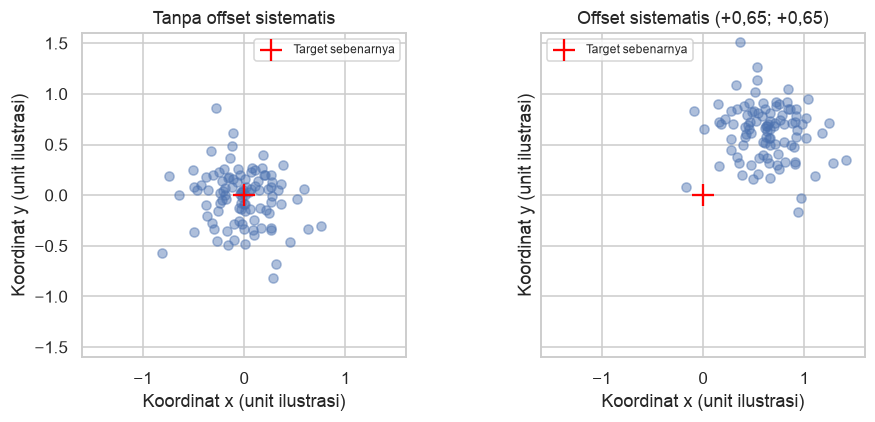

In [2]:
rng = np.random.default_rng(SEED)
noise = rng.normal(0, .3, (100,2))
fig,axes = plt.subplots(1,2,figsize=(9,4),sharex=True,sharey=True)
for ax,points,title in zip(axes,[noise,noise+[.65,.65]],['Tanpa offset sistematis','Offset sistematis (+0,65; +0,65)']):
    ax.scatter(points[:,0],points[:,1],alpha=.45)
    ax.scatter(0,0,marker='+',s=200,c='red',label='Target sebenarnya')
    ax.set(xlim=(-1.6,1.6),ylim=(-1.6,1.6),xlabel='Koordinat x (unit ilustrasi)',
           ylabel='Koordinat y (unit ilustrasi)',title=title,aspect='equal')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Kedua panel memiliki noise yang sama. Panel kanan tetap bergeser walaupun jumlah titik ditambah; perbaikan memerlukan koreksi proses, bukan hanya penambahan data.

<a id="c2-03"></a>
## Random Selection

*Acuan: cetak 51; PDF 69. Jenis: Teori + demonstrasi tambahan pada data buku.*

Sebelum mengacak, tentukan siapa yang termasuk populasi: pelanggan aktif, transaksi valid, periode waktu, dan pengecualian uji internal. Pengacakan dari daftar yang tidak lengkap masih menghasilkan bias cakupan. **Stratified sampling** membagi populasi ke strata lalu mengambil sampel acak di setiap strata; jika proporsi strata diubah, estimasi populasi mungkin membutuhkan bobot.

Contoh tambahan berikut memperlihatkan reproducibility pada dataset pendapatan. Seed tetap memudahkan pembandingan, bukan membuat sampel pasti representatif.

In [3]:
sample_preview = income.sample(n=10, replace=False, random_state=SEED)
display(sample_preview.rename('sampel pendapatan (USD)').to_frame())
assert sample_preview.index.is_unique

,sampel pendapatan (USD)
26247,15000
35067,150000
34590,95000
16668,60000
12196,28000
2600,56000
9047,40800
2206,50000
25607,74000
11606,75000


<a id="c2-04"></a>
## Size Versus Quality: When Does Size Matter?

*Acuan: cetak 52; PDF 70. Jenis: Teori.*

Sampel kecil yang bersih dan representatif bisa lebih berguna daripada data sangat besar yang bias. Pemeriksaan missing value, unit, dan pencilan juga lebih mudah pada subset awal. Akan tetapi, proses jarang dan matriks sangat sparse memerlukan banyak data agar contoh relevan terkumpul. Buku memakai pencarian web sebagai ilustrasi: sebuah kombinasi kueri langka membutuhkan volume keseluruhan besar.

Dalam Teknik Komputer, jutaan log normal mungkin diperlukan untuk memperoleh cukup contoh kegagalan yang jarang. Ukuran dataset dan jumlah kejadian yang informatif adalah dua hal berbeda.

<a id="c2-05"></a>
## Sample Mean Versus Population Mean

*Acuan: cetak 53; PDF 71. Jenis: Teori + demonstrasi tambahan.*

Mean sampel $\bar{x}=\frac{1}{n}\sum_i x_i$ mengestimasi mean populasi $\mu$. Huruf $n$ menunjukkan ukuran sampel, $N$ ukuran populasi. Parameter populasi tetap tetapi biasanya tidak diketahui; statistik sampel dapat berubah.

Di bawah ini $\mu_{emp}$ adalah mean seluruh file, hanya benchmark empiris untuk latihan. Menyebutnya mean pendapatan seluruh AS tidak dibenarkan.

In [4]:
print(f'Mean populasi empiris N={len(income):,}: USD {income.mean():,.2f}')
print(f'Mean sampel n=10: USD {sample_preview.mean():,.2f}')

Mean populasi empiris N=50,000: USD 68,760.52
Mean sampel n=10: USD 64,380.00


**Interpretasi dan catatan belajar.** Selisih kedua mean dapat muncul karena sampling acak. Satu selisih tidak cukup untuk menilai apakah proses sampling bias; bias berkaitan dengan kecenderungan sistematis dalam pengulangan.

<a id="c2-06"></a>
## Selection Bias

*Acuan: cetak 54; PDF 72. Jenis: Padanan Python contoh naratif buku.*

Pemilihan pola **setelah melihat hasil** dapat menghasilkan temuan kebetulan. Data snooping dan vast search effect terjadi ketika sangat banyak model, subset, atau pertanyaan dicoba lalu hanya yang menarik dilaporkan. Mitigasinya antara lain menetapkan hipotesis sebelumnya, memakai holdout yang tidak disentuh selama pemilihan, dan target shuffling untuk benchmark kebetulan.

Contoh buku: 10 lemparan koin semuanya heads tampak langka untuk satu orang. Jika 20.000 orang mencoba secara independen, peluang setidaknya satu keberhasilan menjadi $1-(1-2^{-10})^{20000}$.

In [5]:
p_ten_heads = .5**10
p_any = -np.expm1(20000*np.log1p(-p_ten_heads))
print(f'P(10 heads untuk satu orang) = {p_ten_heads:.8f}')
print(f'P(setidaknya satu dari 20.000) = {p_any:.10f}')

P(10 heads untuk satu orang) = 0.00097656
P(setidaknya satu dari 20.000) = 0.9999999967


**Interpretasi dan catatan belajar.** Memilih pemenang setelah 20.000 percobaan memberi kesan keahlian yang bisa dijelaskan oleh peluang biasa. Rumus ini mengasumsikan koin adil dan percobaan independen.

<a id="c2-07"></a>
## Regression to the Mean

*Acuan: cetak 55; PDF 73. Jenis: Teori.*

Pengamatan yang sangat ekstrem sering diikuti pengamatan lebih dekat ke pusat, terutama ketika nilai mengandung komponen kemampuan stabil dan keberuntungan sementara. Pemain terbaik pada musim pertama dipilih berdasarkan keduanya; keberuntungan ekstrem tidak harus berulang. Ini bukan gaya fisik yang “menarik” semua nilai ke mean dan bukan metode linear regression pada Bab 4.

Jika peserta dengan hasil buruk dipilih untuk pelatihan lalu membaik, perbaikan tidak otomatis efek pelatihan. Kelompok kontrol yang dipilih dengan cara serupa membantu memisahkan efek intervensi dari regression to the mean.

<a id="c2-08"></a>
## Sampling Distribution of a Statistic

*Acuan: cetak 57; PDF 75. Jenis: Reproduksi Python buku.*

**Data distribution** adalah distribusi nilai individu. **Sampling distribution** adalah distribusi statistik dari banyak sampel berukuran sama. Reproduksi Gambar 2-6 mengambil 1.000 pendapatan individu, 1.000 mean sampel berukuran 5, dan 1.000 mean sampel berukuran 20.

Setiap sampel ditarik tanpa replacement seperti kode Python buku; antarulangannya record boleh muncul lagi. RandomState dipakai bersama agar hasil dapat diulang. Rentang histogram mengikuti buku (USD0–200.000), sehingga observasi di luar rentang tidak terlihat; statistik ringkasan tetap menggunakan seluruh hasil.

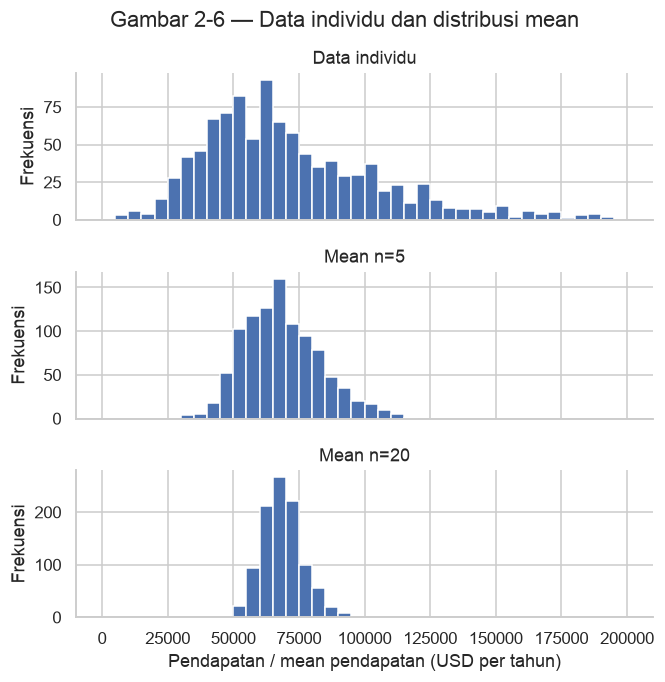

,mean,std,skew
type,,,
Data individu,70567.1700,33408.565073,1.010058
Mean n=5,68633.5564,14597.491251,0.466983
Mean n=20,68788.7336,7625.452943,0.479164


Jumlah hasil di luar USD0–200.000:


,outside
type,
Data individu,0
Mean n=5,0
Mean n=20,0


In [6]:
rs = np.random.RandomState(SEED)
sampling = pd.concat([
    pd.DataFrame({'income':income.sample(1000,random_state=rs).to_numpy(),'type':'Data individu'}),
    pd.DataFrame({'income':[income.sample(5,random_state=rs).mean() for _ in range(1000)],'type':'Mean n=5'}),
    pd.DataFrame({'income':[income.sample(20,random_state=rs).mean() for _ in range(1000)],'type':'Mean n=20'}),
],ignore_index=True)
g=sns.FacetGrid(sampling,col='type',col_wrap=1,height=2,aspect=3,sharey=False)
g.map(plt.hist,'income',range=[0,200000],bins=40)
g.set_axis_labels('Pendapatan / mean pendapatan (USD per tahun)','Frekuensi')
g.set_titles('{col_name}')
g.figure.suptitle('Gambar 2-6 — Data individu dan distribusi mean',y=1.03)
plt.show()
display(sampling.groupby('type',sort=False).income.agg(['mean','std','skew']))
print('Jumlah hasil di luar USD0–200.000:')
display(sampling.assign(outside=~sampling.income.between(0,200000))
        .groupby('type',sort=False).outside.sum().to_frame())

**Interpretasi dan catatan belajar.** Pendapatan individu menceng ke kanan. Mean dari 20 pengamatan lebih terpusat dan kurang menceng daripada nilai individu. Merata-ratakan menurunkan variasi statistik; tidak mengubah distribusi pendapatan orang sebenarnya.

<a id="c2-09"></a>
## Central Limit Theorem

*Acuan: cetak 60; PDF 78. Jenis: Teori.*

Dalam bentuk klasik, untuk sampel independen dan identik dengan mean $\mu$ serta varians terbatas $\sigma^2$, $\sqrt{n}(\bar X-\mu)/\sigma$ mendekati normal standar saat $n$ membesar. Teorema ini menjelaskan **mean yang distandardisasi**, bukan menjamin data mentah normal.

Tidak ada ambang universal “n=30 selalu cukup”. Ekor berat, korelasi waktu, dan ukuran efektif sampel dapat memperlambat atau menggagalkan pendekatan klasik. Grafik mean n=5 dan n=20 memberikan ilustrasi empiris, bukan bukti bahwa semua statistik otomatis normal.

<a id="c2-10"></a>
## Standard Error

*Acuan: cetak 60; PDF 78. Jenis: Perhitungan tambahan untuk menjelaskan contoh buku.*

SD mengukur variasi individu; **SE** mengukur variasi estimator. Untuk mean sampel i.i.d., estimasi $SE(\bar X)=s/\sqrt n$. Jika sampling tanpa replacement mengambil bagian besar dari populasi berukuran $N$, kalikan dengan finite-population correction $\sqrt{(N-n)/(N-1)}$.

Meningkatkan ukuran sampel empat kali mengurangi SE mean kira-kira separuh. Rumus $s/\sqrt n$ bukan rumus umum untuk median atau data berautokorelasi; gunakan metode yang sesuai statistik dan desain sampling.

In [7]:
display(pd.DataFrame([
    {'n':k,'SE rumus (USD)':income.std(ddof=1)/np.sqrt(k),
     'SD mean simulasi (USD)':sampling.loc[sampling.type==f'Mean n={k}','income'].std(ddof=1)}
    for k in [5,20]]))

,n,SE rumus (USD),SD mean simulasi (USD)
0,5,14700.821129,14597.491251
1,20,7350.410565,7625.452943


**Interpretasi dan catatan belajar.** SD dari 1.000 mean mendekati SE teoretis, dengan variasi Monte Carlo. Selisih kecil wajar karena hanya 1.000 pengulangan dan distribusi pendapatan memiliki ekor panjang.

<a id="c2-11"></a>
## The Bootstrap

*Acuan: cetak 61; PDF 79. Jenis: Reproduksi Python buku.*

Bootstrap menggambar sampel ukuran $n$ **dengan replacement dari data teramati**, menghitung statistik, lalu mengulangnya $B$ kali. Seluruh baris harus ditarik bersama jika ada banyak kolom; mengambil kolom secara terpisah merusak pasangan. Pada model prediksi, agregasi model bootstrap menghasilkan ide bagging.

Di sini statistiknya median pendapatan dan $B=1000$, sesuai buku. Bias bootstrap $\widehat{bias}=\overline{\theta^*}-\hat\theta$; SE bootstrap adalah SD dari $\theta^*$, bukan SD data awal. Bootstrap i.i.d. mengasumsikan sampel cukup mewakili populasi dan unit independen. Bootstrap tidak menciptakan informasi baru, memperbaiki bias sampling, atau menemukan kelompok yang sama sekali tidak teramati.

In [8]:
rs_boot = np.random.RandomState(SEED)
boot_median = pd.Series([resample(income,random_state=rs_boot).median() for _ in range(1000)])
boot_summary = pd.Series({'median asli (USD)':income.median(),
                          'bias bootstrap (USD)':boot_median.mean()-income.median(),
                          'SE bootstrap (USD)':boot_median.std(ddof=1)})
display(boot_summary.to_frame('hasil aktual'))
assert income.median()==62000
print('Acuan R buku: median 62000; bias -70.5595; SE 209.1515 (hasil acak).')

,hasil aktual
median asli (USD),62000.000000
bias bootstrap (USD),-69.884500
SE bootstrap (USD),211.650315


Acuan R buku: median 62000; bias -70.5595; SE 209.1515 (hasil acak).


**Interpretasi dan catatan belajar.** Median asli harus cocok pada USD62.000. Bias dan SE tidak diharapkan identik dengan output R karena generator dan seed berbeda. Nilai tersebut menunjukkan ketidakstabilan median pada populasi yang menyerupai sampel, bukan akurasi pendapatan seluruh penduduk. Pada eksekusi ini bias bootstrap ≈−USD69,88 dan SE ≈USD211,65; bias kecil relatif terhadap median USD62.000 dalam model empiris ini.

<a id="c2-12"></a>
## Resampling Versus Bootstrapping

*Acuan: cetak 65; PDF 83. Jenis: Teori.*

Resampling adalah istilah payung. Bootstrap mengambil sampel dengan replacement untuk mengukur ketidakpastian estimasi. Permutation mengacak penempatan label/kelompok untuk meniru hipotesis nol dan dibahas pada Bab 3. Menukar keduanya tanpa menyesuaikan pertanyaan mengubah makna distribusi acuan.

Untuk time series, bootstrap per baris secara acak menghapus ketergantungan waktu; block bootstrap lebih sesuai bila ingin mempertahankan dependensi lokal. Metode blok tidak menjadi contoh komputasi wajib dalam bab ini.

<a id="c2-13"></a>
## Confidence Intervals

*Acuan: cetak 65; PDF 83. Jenis: Reproduksi kode pendamping Python.*

Interval kepercayaan menyampaikan ketidakpastian estimasi. **Percentile bootstrap CI** tingkat $1-\alpha$ menggunakan $[Q_{\alpha/2}(\theta^*), Q_{1-\alpha/2}(\theta^*)]$. Ambil 20 pendapatan tanpa replacement dengan seed 3 dan bootstrap mean 500 kali seperti kode pendamping untuk Gambar 2-9.

Pada interpretasi frequentist, prosedur CI 95% akan mencakup **parameter populasi tetap** sekitar 95% dalam pengambilan sampel berulang jika asumsi dan pendekatannya layak. Setelah satu interval dihitung, bukan berarti ada probabilitas frequentist 95% bahwa parameter tetap “bergerak” di dalam interval. CI mean juga bukan rentang untuk 95% pendapatan individu. Percentile bootstrap dari n=20 yang menceng bisa memiliki coverage buruk; hasil ini latihan, bukan jaminan ketepatan 95%.

,batas bawah (USD),batas atas (USD)
90%,43212.4500,70233.4400
95%,41262.2225,72893.7725


Mean sampel 20: USD 55,734.10; mean seluruh file: USD 68,760.52


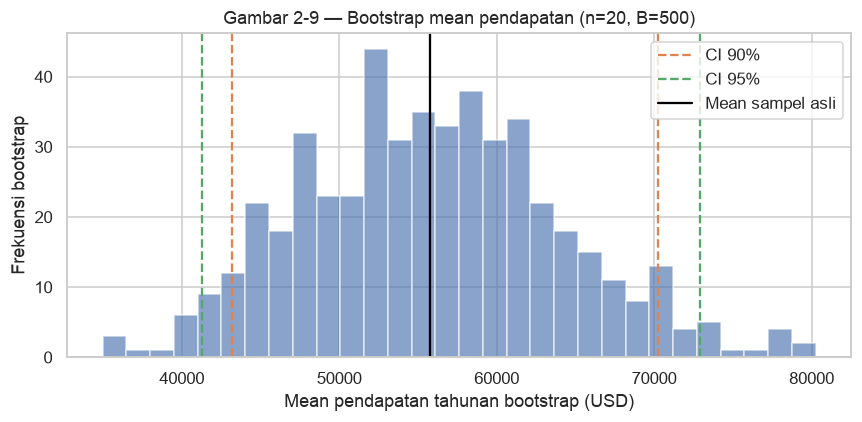

In [9]:
rs_ci=np.random.RandomState(3)
sample20=resample(income,n_samples=20,replace=False,random_state=rs_ci)
boot_mean=pd.Series([resample(sample20,random_state=rs_ci).mean() for _ in range(500)])
ci90=boot_mean.quantile([.05,.95]).to_numpy()
ci95=boot_mean.quantile([.025,.975]).to_numpy()
display(pd.DataFrame([ci90,ci95],index=['90%','95%'],columns=['batas bawah (USD)','batas atas (USD)']))
print(f'Mean sampel 20: USD {sample20.mean():,.2f}; mean seluruh file: USD {income.mean():,.2f}')
fig,ax=plt.subplots(figsize=(8,4))
ax.hist(boot_mean,bins=30,alpha=.65)
for ci,color,label in [(ci90,'C1','CI 90%'),(ci95,'C2','CI 95%')]:
    for j,x in enumerate(ci): ax.axvline(x,color=color,ls='--',label=label if j==0 else None)
ax.axvline(sample20.mean(),color='black',label='Mean sampel asli')
ax.set(title='Gambar 2-9 — Bootstrap mean pendapatan (n=20, B=500)',
       xlabel='Mean pendapatan tahunan bootstrap (USD)',ylabel='Frekuensi bootstrap')
ax.legend(); plt.tight_layout(); plt.show()
assert ci95[0] <= ci90[0] <= ci90[1] <= ci95[1]

**Interpretasi dan catatan belajar.** CI 95% lebih lebar dari CI 90% karena mencakup lebih banyak distribusi bootstrap. Mean sampel dapat berbeda dari USD62.231 pada gambar R buku: seed Python memilih sampel yang berbeda. Gunakan output aktual di atas untuk menjelaskan interval, bukan menyalin endpoint dari gambar buku. Untuk sampel aktual dengan mean USD55.734,10, CI bootstrap 90% sekitar USD43.212–70.233 dan CI 95% sekitar USD41.262–72.894; keduanya menyatakan ketidakpastian mean, bukan rentang pendapatan seseorang.

<a id="c2-14"></a>
## Normal Distribution

*Acuan: cetak 69; PDF 87. Jenis: Reproduksi ilustrasi distribusi pendamping.*

Normal/Gaussian memiliki parameter mean $\mu$ dan SD $\sigma>0$:
$$f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp[-(x-\mu)^2/(2\sigma^2)].$$
Distribusinya simetris; sekitar 68% berada dalam satu SD dan 95% dalam dua SD. Nama “normal” tidak berarti semua fenomena harus mengikutinya. Penggunaan model normal terutama berguna ketika mekanisme penjumlahan error atau sampling mendukungnya.

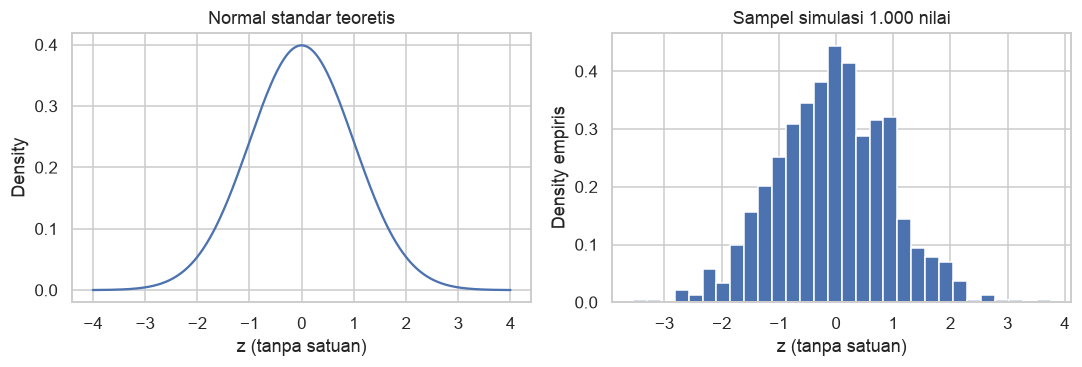

P(|Z| ≤ 1) = 0.6826894921370859
P(|Z| ≤ 2) = 0.9544997361036416


In [10]:
x=np.linspace(-4,4,400)
rng_normal=np.random.default_rng(SEED)
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
axes[0].plot(x,stats.norm.pdf(x)); axes[0].set(title='Normal standar teoretis',ylabel='Density')
axes[1].hist(stats.norm.rvs(size=1000,random_state=rng_normal),bins=30,density=True)
axes[1].set(title='Sampel simulasi 1.000 nilai',ylabel='Density empiris')
for ax in axes: ax.set_xlabel('z (tanpa satuan)')
plt.tight_layout(); plt.show()
print('P(|Z| ≤ 1) =',stats.norm.cdf(1)-stats.norm.cdf(-1))
print('P(|Z| ≤ 2) =',stats.norm.cdf(2)-stats.norm.cdf(-2))

**Interpretasi dan catatan belajar.** Histogram sampel hanya mendekati kurva populasi; ketidakrataan muncul dari jumlah sampel terbatas. Kurva ini merekonstruksi gagasan Gambar 2-1 dan 2-10 dengan simulasi yang dinyatakan eksplisit.

<a id="c2-15"></a>
## Standard Normal and QQ-Plots

*Acuan: cetak 71; PDF 89. Jenis: Reproduksi Python buku.*

Standardisasi $z_i=(x_i-\bar{x})/s$ mengubah pusat dan skala tanpa memperbaiki kemencengan. QQ-plot membandingkan kuantil sampel terurut dengan kuantil distribusi teoretis. Titik hampir lurus mendukung kecocokan bentuk, tetapi bukan bukti absolut; sampel kecil mempunyai variasi acak pada ekor.

Contoh buku menggambar 100 nilai normal standar. `fit=False` menonaktifkan garis regresi otomatis, lalu garis $y=x$ ditambahkan karena skala contoh memang normal standar.

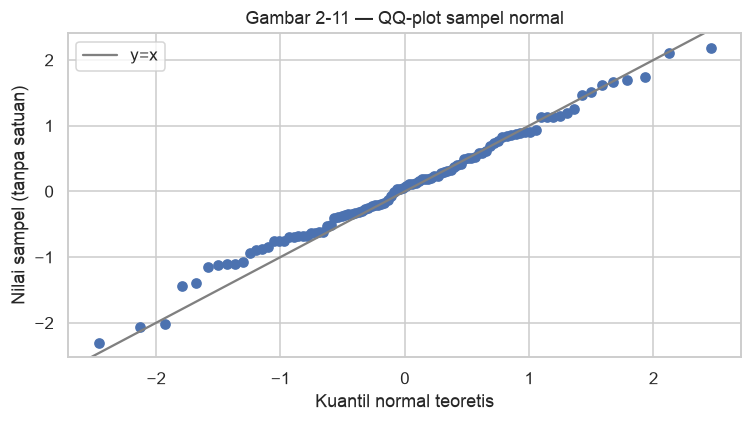

In [11]:
normal_sample=stats.norm.rvs(size=100,random_state=np.random.RandomState(SEED))
fig,ax=plt.subplots()
stats.probplot(normal_sample,dist='norm',fit=False,plot=ax)
ax.axline((0,0),(1,1),color='gray',label='y=x')
ax.set(title='Gambar 2-11 — QQ-plot sampel normal',xlabel='Kuantil normal teoretis',ylabel='Nilai sampel (tanpa satuan)')
ax.legend(); plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Deviasi kecil dari diagonal tetap diharapkan walaupun sampel benar-benar dibangkitkan dari normal. Jangan menganggap setiap titik ekor yang menjauh sebagai data salah.

<a id="c2-16"></a>
## Long-Tailed Distributions

*Acuan: cetak 73; PDF 91. Jenis: Reproduksi literal + audit keterbatasan sumber.*

Long tails berarti nilai ekstrem lebih sering muncul dibanding model berekor ringan seperti normal; skewness menyatakan ketidaksimetrian, sehingga kedua konsep tidak sama. Mengabaikan ekor dapat meremehkan risiko kejadian ekstrem.

**Audit contoh NFLX:** buku menghitung `diff(log(nflx[nflx>0]))`. Kode tersebut direproduksi persis, tetapi file pendamping memuat perubahan bertanda, bukan seri harga positif mentah. Membuang nilai nonpositif dan melakukan log-difference tidak dapat disebut return harian Netflix yang tervalidasi. Penghapusan itu juga membuat titik yang berurutan belum tentu hari yang berurutan. Grafik kedua menstandardisasi hasil transformasi untuk membandingkan bentuk ekor; ini tambahan diagnostik, bukan data pengganti.

Observasi raw: 5647 | dibuang karena ≤0: 4034 | hasil diff: 1612


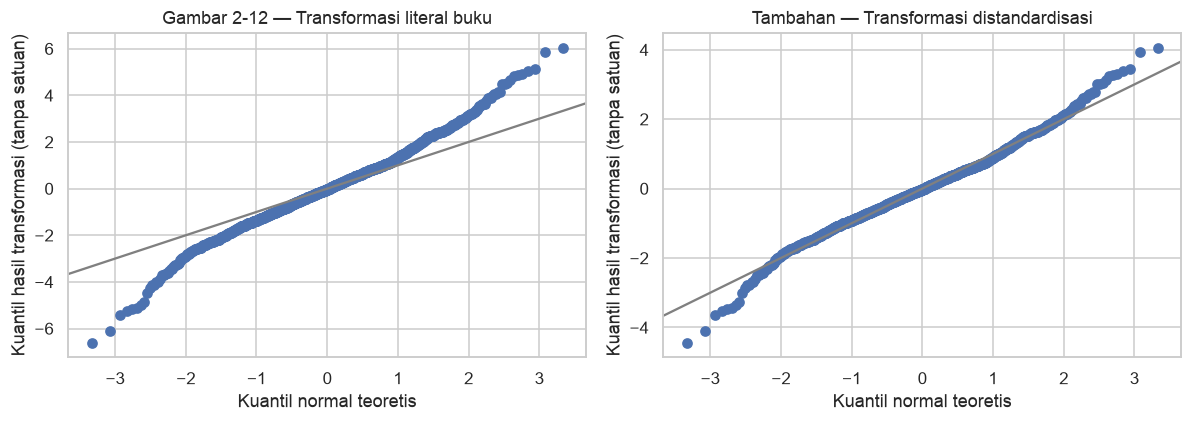

,transformasi buku
count,1612.000000
mean,0.001556
std,1.488791
min,-6.605298
1%,-3.695251
5%,-2.285249
95%,2.456536
99%,3.900856
max,6.037870


In [12]:
nflx_raw=sp500.NFLX
nflx=np.diff(np.log(nflx_raw[nflx_raw>0]))
print('Observasi raw:',len(nflx_raw),'| dibuang karena ≤0:',int((nflx_raw<=0).sum()),
      '| hasil diff:',len(nflx))
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,vals,title in [(axes[0],nflx,'Gambar 2-12 — Transformasi literal buku'),
                       (axes[1],stats.zscore(nflx,ddof=1),'Tambahan — Transformasi distandardisasi')]:
    stats.probplot(vals,fit=False,plot=ax)
    ax.axline((0,0),(1,1),color='gray')
    ax.set(title=title,xlabel='Kuantil normal teoretis',ylabel='Kuantil hasil transformasi (tanpa satuan)')
plt.tight_layout(); plt.show()
display(pd.Series(nflx).describe(percentiles=[.01,.05,.95,.99]).to_frame('transformasi buku'))

**Interpretasi dan catatan belajar.** Penyimpangan ekor pada QQ-plot menunjukkan keterbatasan model normal untuk hasil transformasi ini. Kesimpulan dibatasi pada seri yang dihitung; metadata harga mentah tidak tersedia untuk memvalidasi klaim return pasar. Tidak ada dataset yang diganti atau direkayasa.

<a id="c2-17"></a>
## Student’s t-Distribution

*Acuan: cetak 75; PDF 93. Jenis: Teori + implementasi tambahan rumus buku.*

Distribusi Student t memiliki ekor lebih tebal daripada normal dan mendekati normal saat derajat bebas membesar. Pada sampel i.i.d. normal, statistik $T=(\bar X-\mu)/(S/\sqrt n)$ mengikuti $t_{n-1}$. Mean mentah sendiri tidak otomatis mengikuti t; pembagian oleh estimasi SD itulah bagian pentingnya.

CI mean berbasis t: $\bar{x}\pm t_{1-\alpha/2,n-1}s/\sqrt n$. Pada sampel kecil nonnormal yang sangat menceng, coverage formula ini tidak dijamin. Gosset mengembangkan pendekatan ini sebelum resampling komputer praktis; ilustrasi historisnya dijelaskan tanpa menyalin gambar.

CI t 90% untuk mean sampel20: (np.float64(41235.6270449381), np.float64(70232.5729550619))


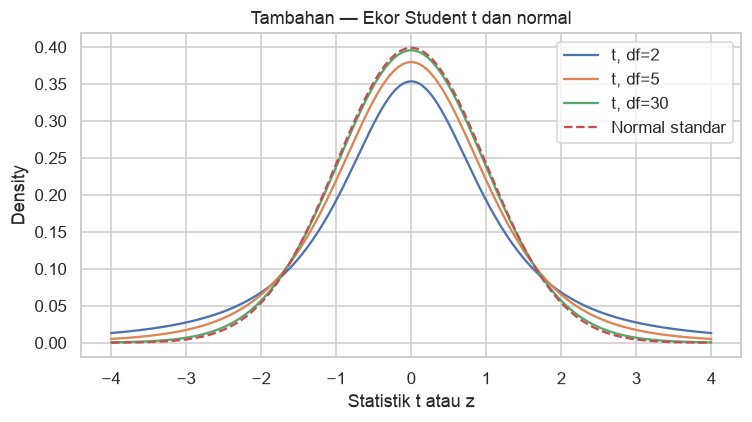

In [13]:
dfree=len(sample20)-1
half=stats.t.ppf(.95,df=dfree)*stats.sem(sample20)
print('CI t 90% untuk mean sampel20:',(sample20.mean()-half,sample20.mean()+half))
x=np.linspace(-4,4,400)
for dfree in [2,5,30]: plt.plot(x,stats.t.pdf(x,dfree),label=f't, df={dfree}')
plt.plot(x,stats.norm.pdf(x),ls='--',label='Normal standar')
plt.title('Tambahan — Ekor Student t dan normal'); plt.xlabel('Statistik t atau z'); plt.ylabel('Density')
plt.legend(); plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Ekor t lebih tebal untuk df kecil, mencerminkan ketidakpastian estimasi skala. CI t dan bootstrap dapat berbeda pada sampel20 yang kecil dan menceng; tidak ada alasan memaksa kedua endpoint sama.

<a id="c2-18"></a>
## Binomial Distribution

*Acuan: cetak 78; PDF 96. Jenis: Reproduksi Python + contoh naratif buku.*

Jika $n$ percobaan independen memiliki peluang sukses tetap $p$, maka $X\sim\operatorname{Binomial}(n,p)$ menghitung banyak sukses. “Sukses” berarti kategori yang diminati, bukan selalu kejadian baik. Bernoulli adalah kasus $n=1$.
$$P(X=k)=\binom nkp^k(1-p)^{n-k},\quad E[X]=np,\quad Var(X)=np(1-p).$$
PMF menghitung peluang **tepat** $k$, CDF peluang **paling banyak** $k$. Ketergantungan antarklik atau perubahan peluang antarorang melanggar model binomial sederhana.

In [14]:
pmf=stats.binom.pmf(2,n=5,p=.1)
cdf=stats.binom.cdf(2,n=5,p=.1)
print(f'P(X=2), n=5 p=0,1: {pmf:.4f}')
print(f'P(X≤2), n=5 p=0,1: {cdf:.5f}')
print(f'P(tanpa konversi dalam 200 klik), p=0,02: {stats.binom.pmf(0,200,.02):.6f}')
assert np.isclose(pmf,.0729)
assert np.isclose(cdf,.99144)

P(X=2), n=5 p=0,1: 0.0729
P(X≤2), n=5 p=0,1: 0.99144
P(tanpa konversi dalam 200 klik), p=0,02: 0.017588


**Interpretasi dan catatan belajar.** CDF lebih besar karena mengikutsertakan 0 dan 1 sukses. Bahkan dengan peluang konversi 2%, nol konversi pada 200 klik masih mungkin; kejadian jarang tidak sama dengan mustahil.

<a id="c2-19"></a>
## Chi-Square Distribution

*Acuan: cetak 80; PDF 98. Jenis: Teori.*

Jika $Z_1,\dots,Z_\nu$ normal standar independen, jumlah kuadratnya mengikuti $\chi^2_\nu$. Nilainya nonnegatif dan bentuknya bergantung pada derajat bebas $\nu$. Dalam tabel kategori, statistik Pearson $\sum(O-E)^2/E$ mendekati distribusi ini di bawah model nol dan syarat expected count yang cukup.

Chi-square mengukur ketidakcocokan hitungan observasi $O$ dengan expected count $E$. Expected count kecil dapat membuat pendekatan asimtotik buruk; Bab 3 membandingkannya dengan permutasi dan exact test. Bagian buku ini terutama teori; tidak diperlukan dataset sintetis untuk menggantikannya.

<a id="c2-20"></a>
## F-Distribution

*Acuan: cetak 82; PDF 100. Jenis: Teori.*

Distribusi F merupakan rasio dua chi-square independen yang masing-masing dibagi derajat bebasnya: $F=(U/\nu_1)/(V/\nu_2)$. Karena itu F mempunyai **dua** parameter df. Pada ANOVA, pembilang mengukur variasi antarkelompok, penyebut variasi dalam kelompok. Rasio yang besar mendukung adanya perbedaan mean, dengan asumsi model yang sesuai.

Distribusi F hanya bernilai nonnegatif. P-value ANOVA mengambil ekor kanan dan tidak dibagi dua. Contoh numerik lengkap ada di Bab 3, sehingga di sini fokus pada alasan distribusi tersebut menjadi acuan.

<a id="c2-21"></a>
## Poisson and Related Distributions

*Acuan: cetak 82; PDF 100. Jenis: Teori.*

Pilih distribusi berdasarkan pertanyaan: **berapa kejadian per interval** → Poisson; **berapa lama hingga kejadian berikutnya** pada laju konstan → eksponensial; **berapa umur hingga gagal** dengan hazard berubah → Weibull. Laju rata-rata, satuan waktu, dan independensi kejadian harus jelas. Lonjakan trafik dan pola harian dapat memerlukan pemisahan periode atau model lain.

<a id="c2-22"></a>
## Poisson Distributions

*Acuan: cetak 83; PDF 101. Jenis: Reproduksi simulasi buku.*

Untuk interval dengan rata-rata hitungan $\lambda$, $P(X=k)=e^{-\lambda}\lambda^k/k!$, dan $E[X]=Var(X)=\lambda$. Jika laju adalah $r$ per menit dan intervalnya $t$ menit, gunakan $\lambda=rt$. Contoh buku mensimulasikan 100 menit dengan rata-rata 2 panggilan per menit.

Model mengasumsikan kejadian independen dengan laju yang cukup stabil. Overdispersion (varians jauh lebih besar dari mean) dapat menandakan heterogenitas laju atau pengelompokan kejadian.

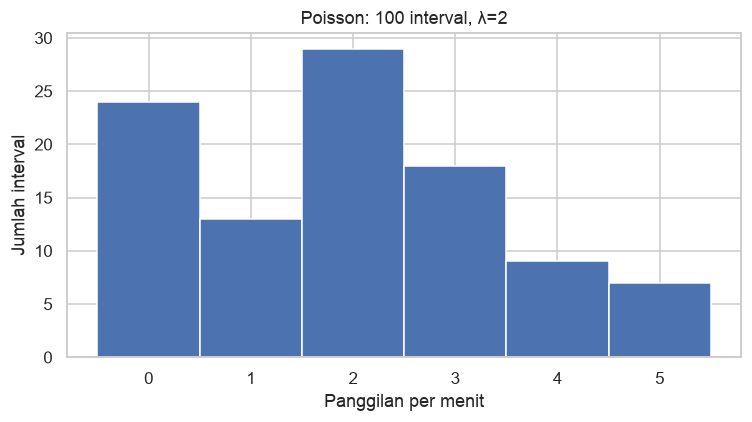

Mean simulasi: 1.96 | varians sampel: 2.2812121212121212 | teori: 2


In [15]:
poisson_sample=stats.poisson.rvs(2,size=100,random_state=np.random.RandomState(SEED))
plt.hist(poisson_sample,bins=np.arange(poisson_sample.max()+2)-.5,edgecolor='white')
plt.title('Poisson: 100 interval, λ=2'); plt.xlabel('Panggilan per menit'); plt.ylabel('Jumlah interval')
plt.tight_layout(); plt.show()
print('Mean simulasi:',poisson_sample.mean(),'| varians sampel:',poisson_sample.var(ddof=1),'| teori: 2')

**Interpretasi dan catatan belajar.** Hitungan setiap menit bervariasi walaupun laju rata-rata tetap. Mean dan varians simulasi tidak harus tepat 2 karena hanya 100 interval; parameter 2 berasal dari skenario buku.

<a id="c2-23"></a>
## Exponential Distribution

*Acuan: cetak 84; PDF 102. Jenis: Reproduksi dengan koreksi parameter SciPy.*

Pada proses Poisson homogen dengan laju $\lambda$, waktu tunggu $T$ mempunyai $f(t)=\lambda e^{-\lambda t}$, $t\ge0$, dan $E[T]=1/\lambda$. Distribusi ini memoryless: peluang menunggu tambahan waktu tidak bergantung pada waktu yang sudah berlalu.

**Koreksi kode cetak:** `stats.expon.rvs(0.2, size=100)` memberi parameter lokasi 0,2, bukan rate 0,2. Padanan yang benar untuk R `rexp(..., rate=0.2)` ialah `scale=1/0.2=5, loc=0`, seperti perbaikan dalam kode pendamping. Satuan contoh adalah menit.

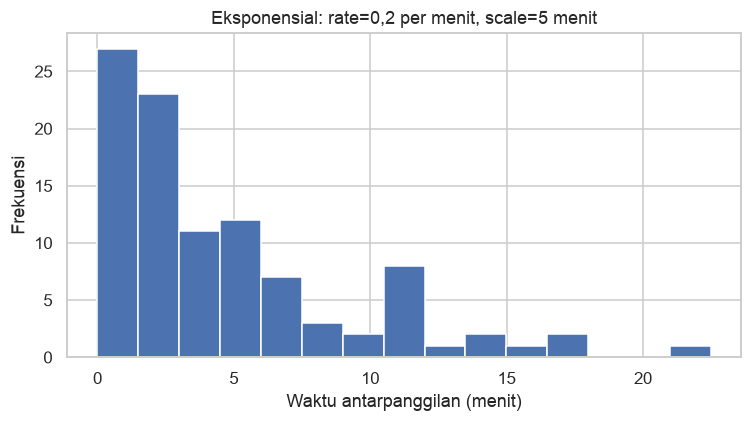

Mean simulasi = 4.741 menit; mean teori = 5 menit


In [16]:
exponential=stats.expon.rvs(scale=5,loc=0,size=100,random_state=np.random.RandomState(SEED))
plt.hist(exponential,bins=15,edgecolor='white')
plt.title('Eksponensial: rate=0,2 per menit, scale=5 menit')
plt.xlabel('Waktu antarpanggilan (menit)'); plt.ylabel('Frekuensi')
plt.tight_layout(); plt.show()
print(f'Mean simulasi = {exponential.mean():.3f} menit; mean teori = 5 menit')

**Interpretasi dan catatan belajar.** Banyak interval pendek dan sedikit interval panjang menghasilkan kemencengan kanan. Rate dan scale berbanding terbalik; angka 0,2 tidak boleh dimasukkan sebagai scale jika ingin meniru contoh buku.

<a id="c2-24"></a>
## Estimating the Failure Rate

*Acuan: cetak 84; PDF 102. Jenis: Teori + perhitungan tambahan dari skenario buku.*

Untuk kejadian jarang, nol kegagalan teramati tidak berarti laju kegagalan nol. Dengan model Poisson homogen, peluang tidak ada kejadian selama $T$ adalah $e^{-\lambda T}$. Contoh naratif buku menyebut 20 jam tanpa kegagalan. Sebagai perhitungan tambahan, batas atas satu sisi 95% memenuhi $e^{-\lambda_U T}=0.05$, sehingga $\lambda_U=-\log(0.05)/T$.

Batas ini mengandalkan model Poisson dan exposure yang lengkap. Ini ilustrasi statistik, bukan sertifikasi keandalan perangkat atau pesawat.

In [17]:
T=20
upper=-np.log(.05)/T
print(f'P(0 kegagalan dalam 20 jam bila rate=1/jam): {np.exp(-T):.3e}')
print(f'Batas atas satu sisi 95% rate setelah 0 kejadian / 20 jam: {upper:.4f} per jam')

P(0 kegagalan dalam 20 jam bila rate=1/jam): 2.061e-09
Batas atas satu sisi 95% rate setelah 0 kejadian / 20 jam: 0.1498 per jam


**Interpretasi dan catatan belajar.** Nol observasi menolak laju yang sangat tinggi, tetapi masih konsisten dengan banyak laju positif yang lebih kecil. Yang diperoleh di sini adalah batas atas laju, bukan perkiraan umur alat yang pasti.

<a id="c2-25"></a>
## Weibull Distribution

*Acuan: cetak 85; PDF 103. Jenis: Reproduksi simulasi buku.*

Weibull memodelkan umur $t\ge0$ dengan shape $\beta>0$ dan scale $\eta>0$: $S(t)=\exp[-(t/\eta)^\beta]$. Hazard $h(t)=\frac{\beta}{\eta}(t/\eta)^{\beta-1}$ meningkat jika $\beta>1$, menurun jika $\beta<1$, dan konstan jika $\beta=1$ (eksponensial).

Contoh buku menggunakan shape 1,5 dan scale 5.000, sebanyak 100 nilai. Buku tidak menetapkan satuan waktu spesifik untuk contoh ini; grafik memakai “unit waktu”. Scale bukan mean dan bukan jaminan semua perangkat bertahan selama itu.

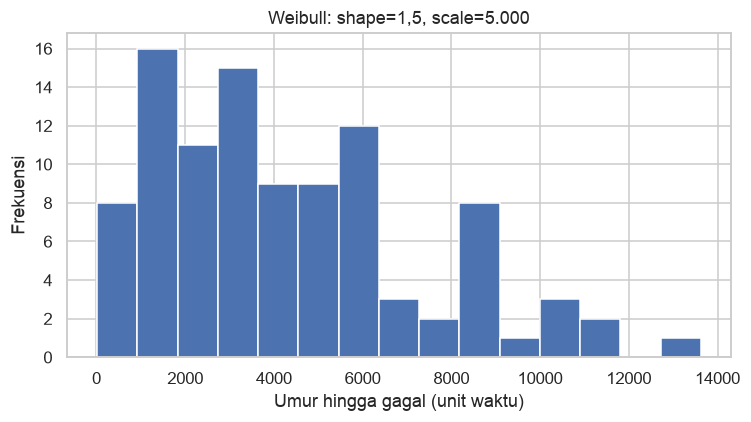

Mean simulasi: 4347.15; mean teori: 4513.73
P(T ≤ 5.000): 0.6321


In [18]:
weibull=stats.weibull_min.rvs(1.5,scale=5000,size=100,random_state=np.random.RandomState(SEED))
plt.hist(weibull,bins=15,edgecolor='white')
plt.title('Weibull: shape=1,5, scale=5.000')
plt.xlabel('Umur hingga gagal (unit waktu)'); plt.ylabel('Frekuensi')
plt.tight_layout(); plt.show()
print(f'Mean simulasi: {weibull.mean():.2f}; mean teori: {stats.weibull_min.mean(1.5,scale=5000):.2f}')
print(f'P(T ≤ 5.000): {stats.weibull_min.cdf(5000,1.5,scale=5000):.4f}')

**Interpretasi dan catatan belajar.** Shape 1,5 berarti hazard meningkat seiring umur. Pada t=scale, sekitar 63,2% distribusi sudah mengalami kejadian. Parameter tersebut tidak diestimasi dari CSV, melainkan ditentukan oleh contoh simulasi buku.

<a id="c2-26"></a>
## Summary

*Acuan: cetak 86; PDF 104. Jenis: Teori.*

Kualitas sampling menentukan apa yang boleh digeneralisasi. Distribusi mean menyempit saat n naik; bootstrap mengestimasi variasi tanpa mewajibkan data mentah normal, tetapi tetap membutuhkan asumsi representativitas dan dependensi yang layak. CI merangkum ketidakpastian parameter; distribusi Poisson, eksponensial, dan Weibull menjawab pertanyaan proses yang berbeda.

**Latihan:** jelaskan mengapa memperbanyak bootstrap tidak sama dengan memperbanyak responden; bedakan SD, SE, CI, dan prediction interval; tentukan model untuk hitungan paket per detik dan waktu antarpaket; jelaskan mengapa transformasi NFLX di sini tidak boleh disebut return pasar yang sudah divalidasi.

**Bacaan lanjutan buku:** Efron–Tibshirani tentang bootstrap, Gosset (1908) tentang t, Taleb tentang kejadian ekstrem, serta Thomas Ryan tentang statistik teknik. Diagram prosedur bootstrap diuraikan melalui langkah algoritme; gambar historis Galton/Gosset tidak disalin.

## Referensi dan atribusi

- Peter Bruce, Andrew Bruce, Peter Gedeck. *Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python*, edisi 2, O’Reilly, 2020. ISBN 978-1-492-07294-2, Bab 2.
- [Kode dan dataset resmi pada commit tetap](https://github.com/gedeck/practical-statistics-for-data-scientists/tree/8a6d3bb6468e979c861d4b37215e1413702dfdfa); sumber khusus: `python/code/Chapter 2*.py` dan notebook pendamping. Copyright kode upstream © 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck. Modifikasi untuk tugas: penjelasan Indonesia, seed, API, pemeriksaan hasil, dan tambahan belajar yang ditandai. Lisensi GPL-3.0: lihat [LICENSE](LICENSE).
- Bacaan lanjutan yang disebut buku dirangkum di bagian akhir bab; rujuk buku untuk bibliografi lengkap.

**Refleksi mahasiswa:** tuliskan bagian yang paling sulit, perubahan kode yang Anda coba, dan satu contoh penerapan pada Teknik Komputer. Jangan mengklaim telah melakukan eksperimen nyata dari data contoh ini.